## **Librerias:**

In [1]:
import pandas as pd
from scipy.stats import shapiro
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

### **Funciones:**

In [2]:
def prueba_normalidad_shap (df, variable):
    stat, p = shapiro(df[variable].dropna())
    print('Estadístico=%.3f, p=%.3f' % (stat, p))

    if p > 0.05:
        print('No se rechaza H0 → parece normal')
    else:
        print('Se rechaza H0 → no es normal')

In [3]:
def analizar_misma_variable(df1, df2, columna, color1="#4682B4", color2="#FF6347"):
    # Crear una figura con dos filas y dos columnas
    f, ((ax_box1, ax_hist1), (ax_box2, ax_hist2)) = plt.subplots(2, 2, sharex='col', figsize=(12, 10))
    
    # Primer par de gráficos (boxplot y histograma para columna en df1)
    sns.boxplot(x=df1[columna], ax=ax_box1, color=color1, fliersize=5)
    ax_box1.set(xlabel='') 
    ax_box1.set_title(f'Distribución de la Variable: {columna} en df1', fontsize=14)
    
    sns.histplot(df1[columna], ax=ax_hist1, kde=True, color=color1, bins=30)
    ax_hist1.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist1.set_ylabel('Frecuencia', fontsize=12)
    
    # Segundo par de gráficos (boxplot y histograma para columna en df2)
    sns.boxplot(x=df2[columna], ax=ax_box2, color=color2, fliersize=5)
    ax_box2.set(xlabel='') 
    ax_box2.set_title(f'Distribución de la Variable: {columna} en df2', fontsize=14)
    
    sns.histplot(df2[columna], ax=ax_hist2, kde=True, color=color2, bins=30)
    ax_hist2.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist2.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()  # Ajustar espaciado
    plt.show()

In [4]:
def analizar_distribucion(df, columna, color="#4682B4"):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                        gridspec_kw={"height_ratios": (.15, .85)},
                                        figsize=(8, 6))
    
    sns.boxplot(x=df[columna], ax=ax_box, color=color, fliersize=5)
    ax_box.set(xlabel='') 
    ax_box.set_title(f'Distribución de la Variable: {columna}', fontsize=14)
    
    sns.histplot(df[columna], ax=ax_hist, kde=True, color=color, bins=30)
    ax_hist.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [5]:
def distribucion_cruzada (df_original, df_imputed, variable):
    sns.kdeplot(df_original[variable].dropna(), label='Original')
    sns.kdeplot(df_imputed[variable], label='Imputado')
    plt.legend()
    plt.show()

In [6]:
def Resumen_Faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    # Mostrar solo columnas con NA
    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

In [69]:
def resumen_var_cat(df, excluir=None, top_n=10):
    """
    df: Serie de pandas
    excluir: valor o lista de valores a excluir
    top_n: número de categorías a mostrar
    """
    
    serie = df.copy()
    
    # Excluir una o varias categorías
    if excluir is not None:
        if isinstance(excluir, list):
            serie = serie[~serie.isin(excluir)]
        else:
            serie = serie[serie != excluir]
    
    conteo = serie.value_counts(dropna=False)
    porcentaje = serie.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(top_n)
    
    styled = resumen.style.format({'porcentaje': '{:.2f}%'})
    display(styled)

In [7]:
def resumen_var_cat(df):
    conteo = df.value_counts(dropna=False)
    porcentaje = df.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(10)  # opcional
    
    # 🎨 estilo bonito
    styled = resumen.style \
        .format({'porcentaje': '{:.2f}%'})
    
    display(styled)

In [8]:
def prueba_kolmogrov(df_original,df_imputed,variable):
    stat, p = ks_2samp(df_original[variable].dropna(), df_imputed[variable].dropna())
    print(f"KS statistic: {stat:.3f}, p-value: {p:.3f}")

    if(p > 0.05):
        print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
    else:
        print("La distribución cambió significativamente")

In [9]:
def imputacion_muestreo_aleatorio(df, df_imputed, variable):
    # 1. Tomar valores reales (sin NA)
    valores = df[variable].dropna()

    # 2. Contar cuántos faltan
    n_faltantes = df[variable].isna().sum()

    # 3. Rellenar con valores aleatorios de la distribución real
    # Asegurándonos de que imputamos sobre el DataFrame correcto (df_imputed)
    df_imputed.loc[df_imputed[variable].isna(), variable] = np.random.choice(
        valores, 
        size=n_faltantes
    )
    
    return df_imputed

In [10]:
def imputacion_por_mediana(df, columna):
    # 1. Calcular la mediana de la columna
    mediana = df[columna].median()

    # 2. Imputar los valores faltantes con la mediana
    df[columna].fillna(mediana, inplace=True)

    return df

## **Cargar datos:**

In [11]:
df = pd.read_excel("df_afro_clean.xlsx")

In [12]:
pd.set_option("display.max_columns", None)
df.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,NaN,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,NaN,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,NaN,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,NaN,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


## **Observando los datos:**

### **Tipos de Datos:**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GRUPO                         1357 non-null   object 
 1   Departamento_Tamizaje         1357 non-null   object 
 2   Municipio_Tamizaje            1357 non-null   object 
 3   Edad                          1357 non-null   int64  
 4   Genero                        1357 non-null   object 
 5   Escolaridad                   1357 non-null   object 
 6   Regimen_Salud                 1357 non-null   object 
 7   Ocupacion                     1357 non-null   object 
 8   Medicacion_Diabetes           1357 non-null   object 
 9   Diabetes_Embarazo             1357 non-null   object 
 10  Hipertension                  1357 non-null   object 
 11  Medicacion_Hipertension       1357 non-null   object 
 12  Colesterol_Alto               1357 non-null   object 
 13  Med

In [14]:
num_registros = len(df)
num_variables = len(df.columns)
num_numericas = df.select_dtypes(include='number').shape[1]
num_categoricas = df.select_dtypes(include='object').shape[1]

print(f"Tenemos un conjunto de datos compuesto por {num_registros} registros y {num_variables} variables, de las cuales {num_numericas} son numéricas y {num_categoricas} son categóricas.")

Tenemos un conjunto de datos compuesto por 1357 registros y 62 variables, de las cuales 12 son numéricas y 50 son categóricas.


### **Nombres de las variables Numéricas:**

In [15]:
df.select_dtypes(include = "number").columns

Index(['Edad', 'Cantidad_Fumador', 'Peso', 'Talla', 'IMC', 'Creatinina',
       'TFG_CDK_EPI', 'TFG_Edad', 'Presion_Sistolica', 'Presion_Diastolica',
       'Presion_Sistolica\t> 130', 'Presion_Diastolica > 90'],
      dtype='object')

### **Nombres de las Variables Categóricas:**

In [16]:
df.select_dtypes(include = "object").columns

Index(['GRUPO', 'Departamento_Tamizaje', 'Municipio_Tamizaje', 'Genero',
       'Escolaridad', 'Regimen_Salud', 'Ocupacion', 'Medicacion_Diabetes',
       'Diabetes_Embarazo', 'Hipertension', 'Medicacion_Hipertension',
       'Colesterol_Alto', 'Medicacion_Colesterol', 'Insuficiencia_Renal',
       'Dialisis', 'Proteina_Sangre_Orina', 'Alergias', 'Nombre_Alergenos',
       'Consumo_Tabaco', 'Fumador_100Cigs', 'Consumo_Alcohol',
       'Frecuencia_Alcohol', 'Embriaguez', 'Consumo_Drogas', 'Trabajo_Cultivo',
       'Uso_Insecticidas', 'Uso_Fungicidas', 'Uso_Fertilizantes',
       'Proteccion_Pesticidas', 'Metodo_Aplicacion_Pesticidas',
       'Sintomas_Trabajo', 'Consumo_Agua_Trabajo', 'Ultima_Consulta_Medica',
       'Dificultad_Atencion_Medica', 'Ultimo_Profesional_Salud',
       'Medico_Cabecera', 'Grupo_Sanguineo', 'Transfusion_Sanguinea',
       'Antecedentes_Familiares', 'Familiar_Insuficiencia_Renal',
       'Familiar_Dialisis', 'Sintomas_Recientes', 'Uso_AINES',
       'Uso_Medic

### **Notas:**

Se evidencia la ausencia de una variable que funcione como identificador único del paciente, lo cual dificulta diferenciar correctamente los registros y garantizar que el formulario no haya sido aplicado más de una vez a la misma persona.

## **Duplicados:**

In [17]:
print("En este dataset podemos encontrar {} resgistros duplicados".format(df.duplicated().sum()))

En este dataset podemos encontrar 1 resgistros duplicados


In [18]:
df[df.duplicated(keep = False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
407,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 5 litros,Mayor a 6 meses,Difícil,Medico General,No,O+,No,Enfermedad Cardiaca,No,No,Ninguno,No,No,Suministro municipal,85,1.8,26.234568,Negativo,NaN,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto
1023,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 5 litros,Mayor a 6 meses,Difícil,Medico General,No,O+,No,Enfermedad Cardiaca,No,No,Ninguno,No,No,Suministro municipal,85,1.8,26.234568,Negativo,NaN,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto


Ante la presencia de un registro duplicado, se procederá a conservar el que aparece en primer lugar y a eliminar aquel que se encuentra en una posición posterior, bajo el supuesto de que el primer registro corresponde a la captura original y los siguientes podrían derivarse de errores de digitación, reprocesamiento o redundancias en la recolección de la información.

In [19]:
df= df.drop_duplicates(keep='first')
print("Dentro del dataset aun quedan {} registros duplicados".format(df.duplicated().sum()))

Dentro del dataset aun quedan 0 registros duplicados


In [20]:
df[df.duplicated(keep=False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC


## **Valores Faltantes:**

A continuación, se procederá a analizar el porcentaje de valores faltantes en cada una de las variables del conjunto de datos.

c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.draw()
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


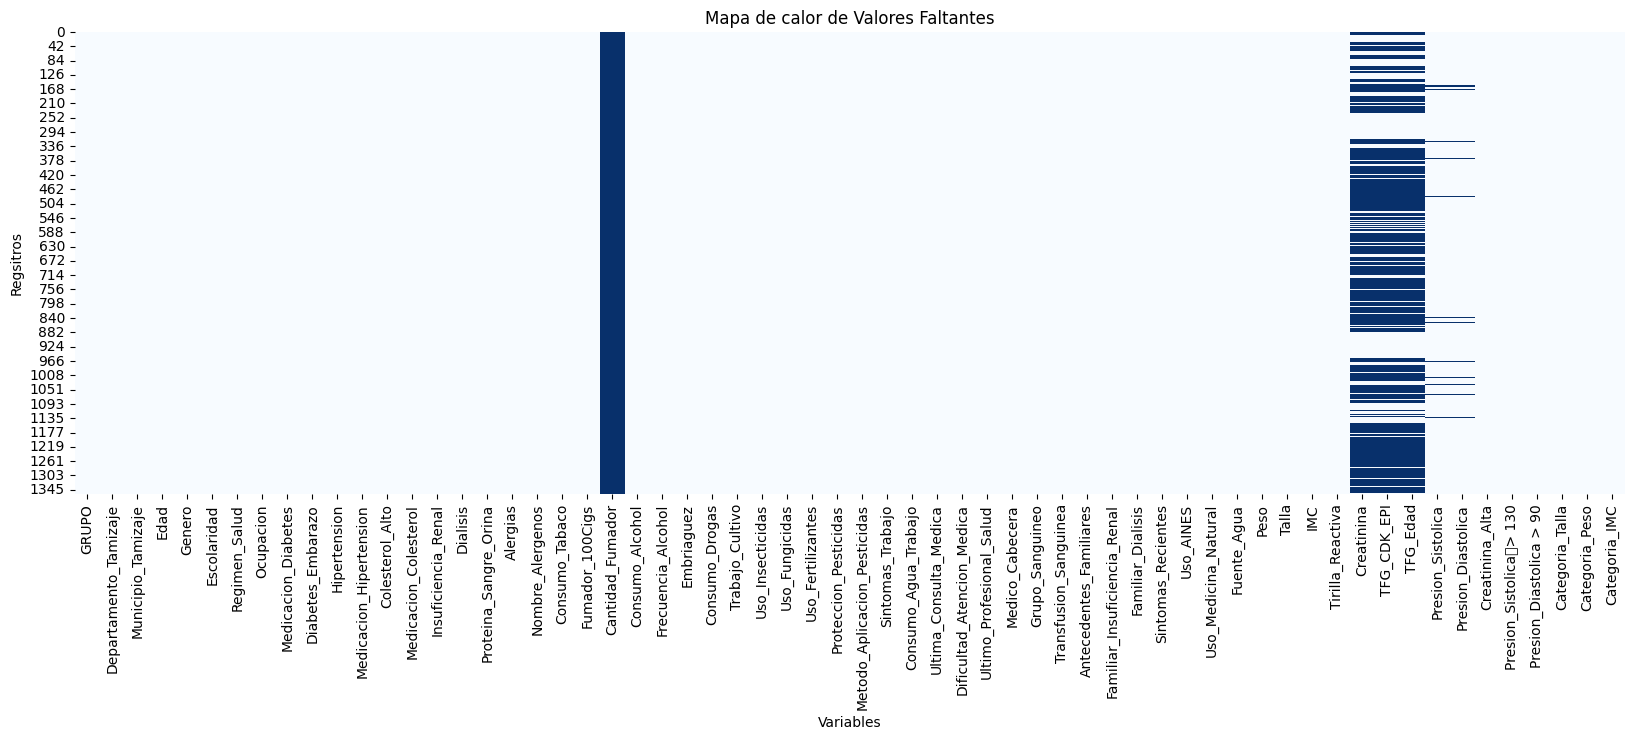

In [21]:
plt.figure(figsize = (20,6))
sns.heatmap(df.isnull(),cbar=False,cmap= "Blues")
plt.title("Mapa de calor de Valores Faltantes")
plt.xlabel("Variables")
plt.ylabel("Regsitros")
plt.show()

In [22]:
Resumen_Faltantes(df)

,Valores faltantes,Porcentaje (%)
Cantidad_Fumador,1356,100.000000
Creatinina,886,65.339233
TFG_CDK_EPI,886,65.339233
TFG_Edad,886,65.339233
Presion_Sistolica,47,3.466077
Presion_Diastolica,47,3.466077


La variable ``Cantidad_Fumador``, al encontrarse completamente vacía, será eliminada de la base de datos.

In [23]:
df = df.drop(columns=['Cantidad_Fumador'])
df.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,NaN,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,NaN,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,NaN,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


 Por otro lado, las variables ``Presion_Sistolica`` y ``Presion_Diastolica`` presentan un 3.46% de valores faltantes (aproximadamente 47 registros), por lo que podrían imputarse mediante medidas de tendencia central como la media o la mediana; no obstante, esta decisión debe evaluarse previamente.

En cuanto a las variables ``Creatinina``, ``TFG_CDK_EPI`` y ``TFG_Edad``, la situación es más compleja, ya que presentan un 65.34% de valores faltantes (alrededor de 886 registros). Dada esta alta proporción, sería necesario considerar métodos de imputación más avanzados, como modelos predictivos. Sin embargo, es fundamental evaluar cuidadosamente que dichos métodos no alteren de manera significativa la distribución original de los datos ni introduzcan sesgos en el análisis.

## **Análisis Variables Numéricas para Imputar:**

### ``Presion_Sistolica``, ``Presion_Diastolica``, `Creatinina`

#### **Distribución con Valores Faltantes:**

In [24]:
df[['TFG_Edad','TFG_CDK_EPI','Creatinina']].describe()

,TFG_Edad,TFG_CDK_EPI,Creatinina
count,470.000000,470.000000,470.000000
mean,82.536170,81.542596,1.156787
std,17.417419,31.470822,0.388140
min,33.000000,22.140000,0.600000
25%,71.250000,54.545000,0.806750
50%,82.000000,78.830000,1.000000
75%,94.000000,105.972500,1.479500
max,116.000000,168.190000,2.500000


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


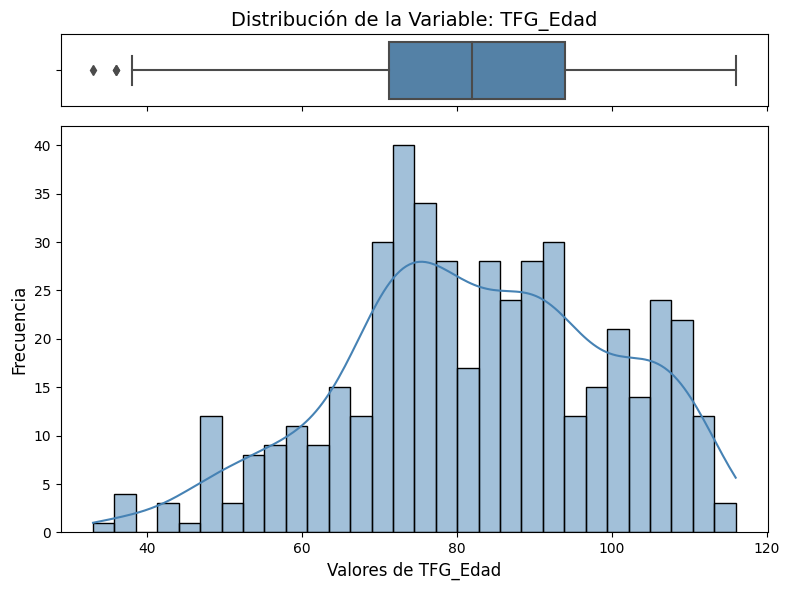

In [25]:
analizar_distribucion(df,"TFG_Edad")

In [26]:
prueba_normalidad_shap(df,"TFG_Edad")

Estadístico=0.982, p=0.000
Se rechaza H0 → no es normal


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


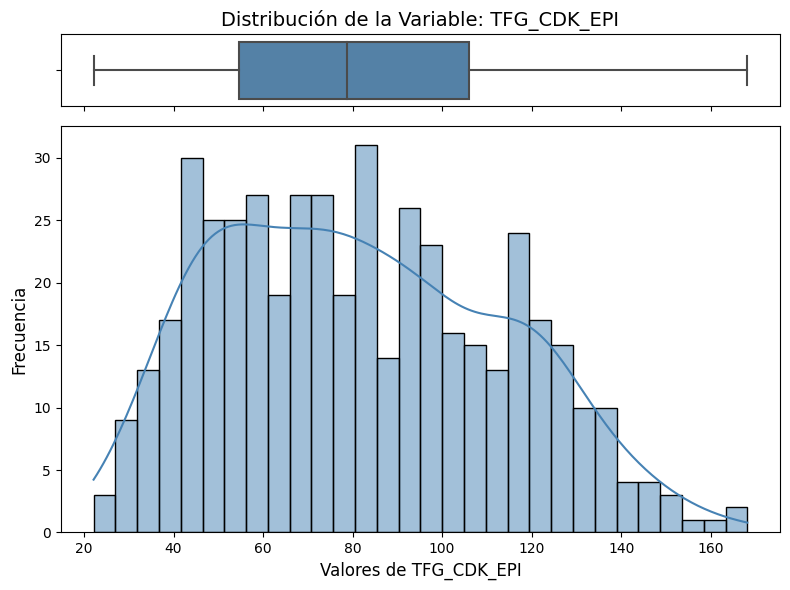

In [27]:
analizar_distribucion(df,"TFG_CDK_EPI")

In [28]:
prueba_normalidad_shap(df,"TFG_CDK_EPI")

Estadístico=0.974, p=0.000
Se rechaza H0 → no es normal


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


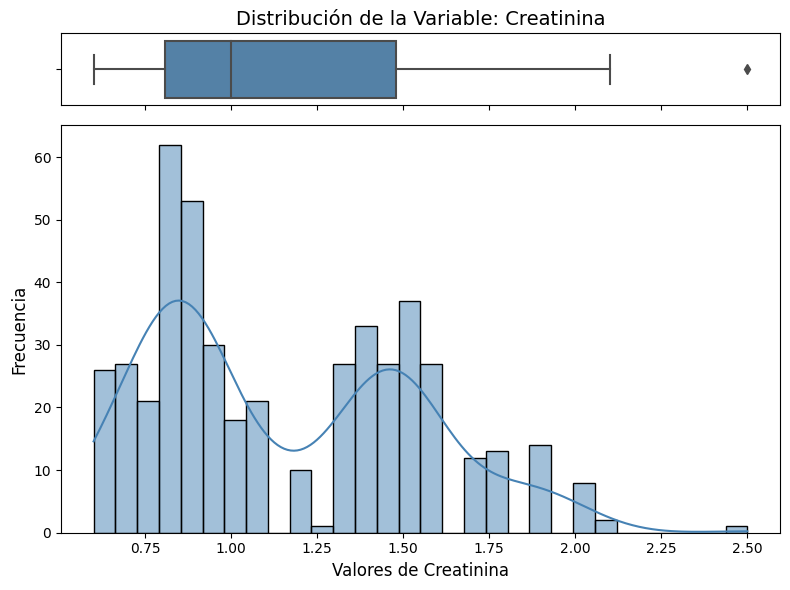

In [29]:
analizar_distribucion(df,"Creatinina")

In [30]:
prueba_normalidad_shap(df,"Creatinina")

Estadístico=0.932, p=0.000
Se rechaza H0 → no es normal


Tenemos que las variables no siguen una distribución normal 

In [31]:
df_original = df.copy()

### **Imputación por Muestreo Aleatorio:**

#### **Creatinina:**

In [32]:
df_imputed = df.copy()

In [33]:
df_imputed = imputacion_muestreo_aleatorio(df_original,df_imputed,"Creatinina")
df_imputed.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,0.8,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,1.4,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,1.8,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

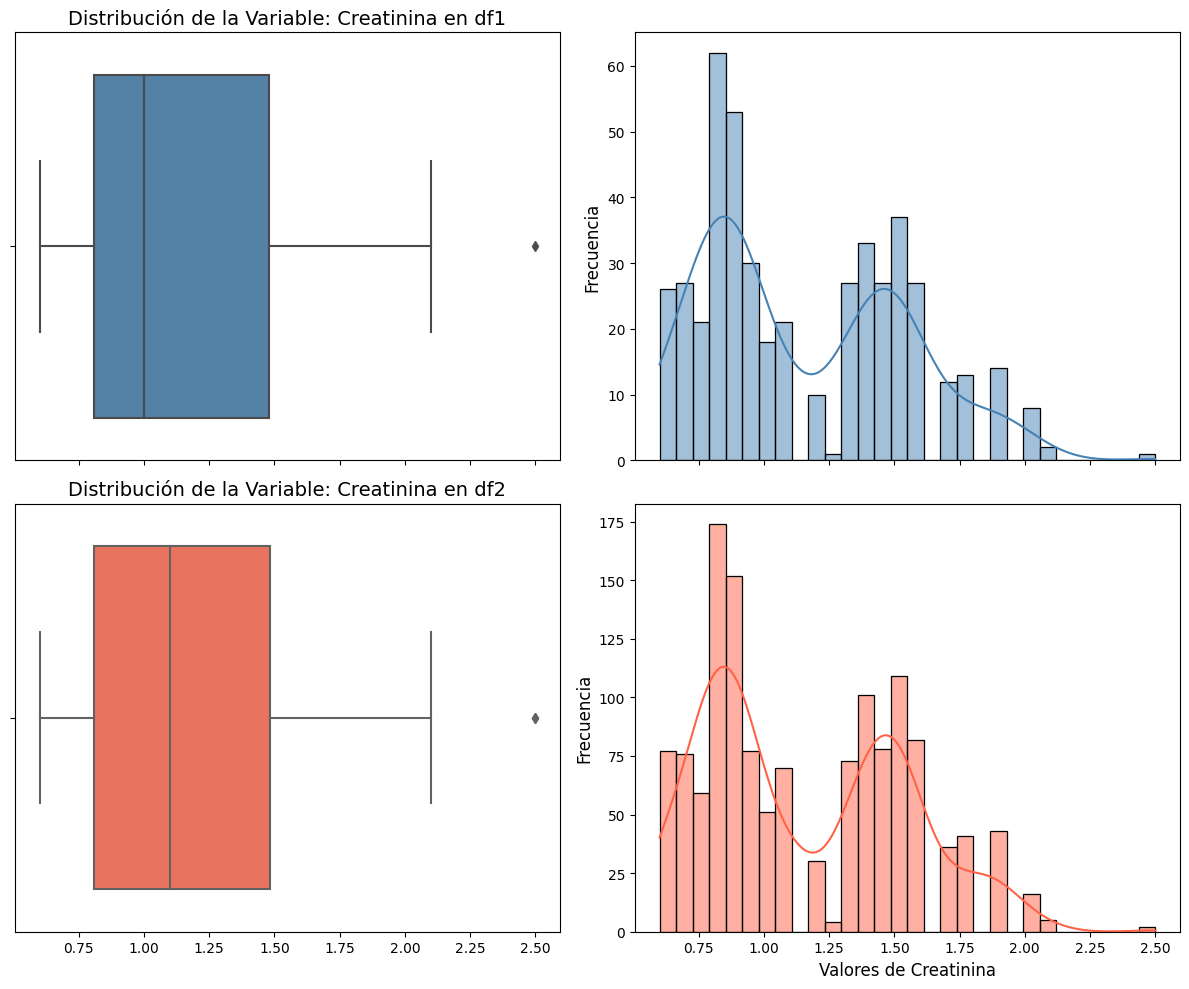

In [34]:
analizar_misma_variable(df_original,df_imputed,"Creatinina")

c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

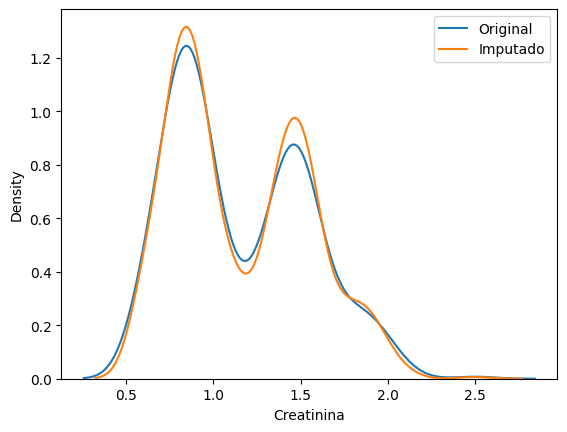

In [35]:
distribucion_cruzada(df_original,df_imputed,"Creatinina")

In [36]:
pd.concat([df_original["Creatinina"].describe(), df_imputed["Creatinina"].describe()], axis=1, 
          keys=["Original", "Imputado"])

,Original,Imputado
count,470.000000,1356.000000
mean,1.156787,1.160049
std,0.388140,0.384398
min,0.600000,0.600000
25%,0.806750,0.808250
50%,1.000000,1.100000
75%,1.479500,1.484000
max,2.500000,2.500000


In [37]:
prueba_kolmogrov(df_original,df_imputed,"Creatinina")


KS statistic: 0.015, p-value: 1.000
No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran


#### **TFG_CDK_EPI**

In [38]:
df_imputed = imputacion_muestreo_aleatorio(df_original,df_imputed,"TFG_CDK_EPI")
df_imputed.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,0.8,108.38,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,1.4,52.51,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,1.8,34.45,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

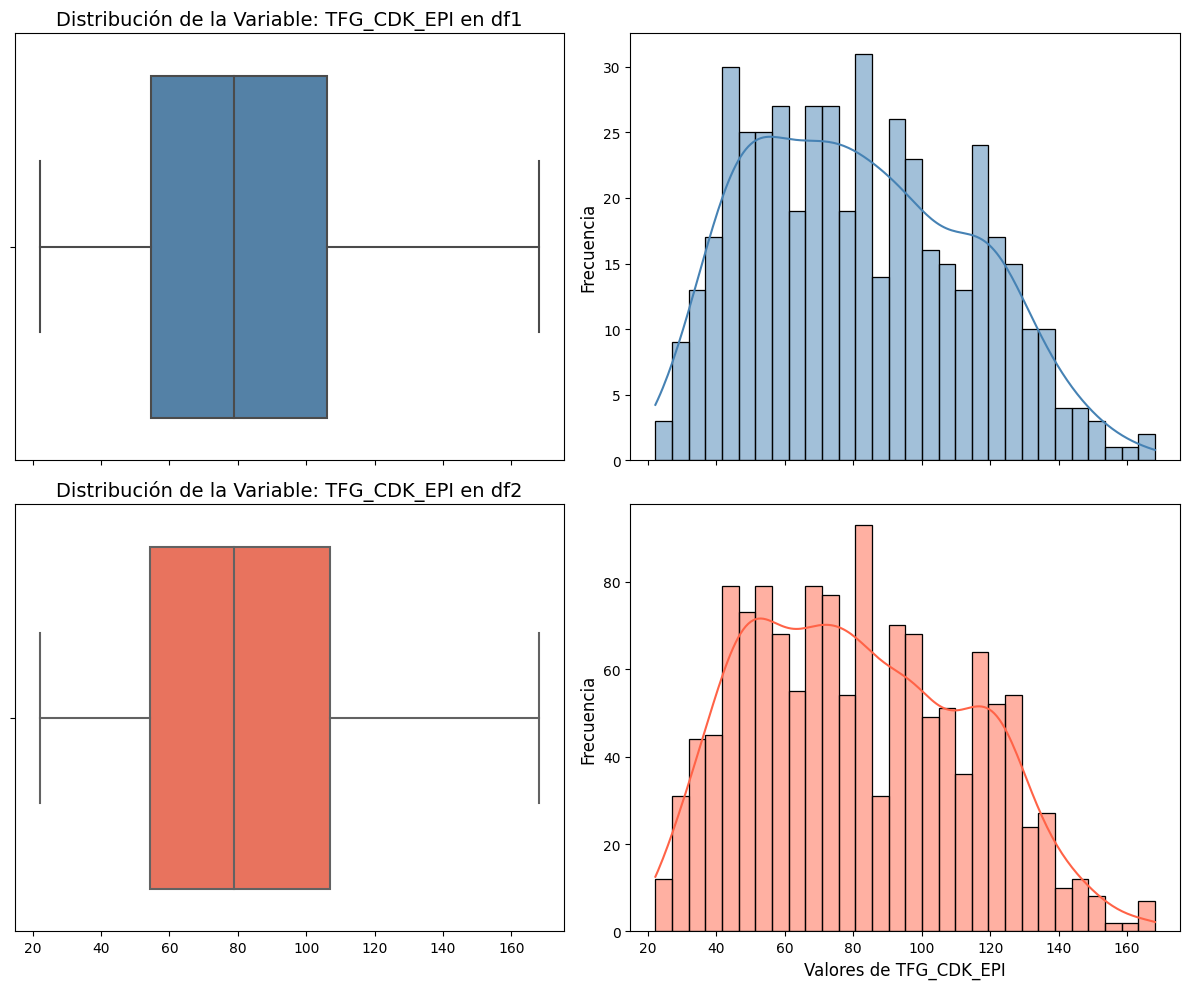

In [39]:
analizar_misma_variable(df_original,df_imputed,"TFG_CDK_EPI")

In [40]:
pd.concat([df_original["TFG_CDK_EPI"].describe(), df_imputed["TFG_CDK_EPI"].describe()], axis=1, 
          keys=["Original", "Imputado"])

,Original,Imputado
count,470.000000,1356.000000
mean,81.542596,81.381232
std,31.470822,31.707121
min,22.140000,22.140000
25%,54.545000,54.235000
50%,78.830000,78.930000
75%,105.972500,106.880000
max,168.190000,168.190000


In [41]:
prueba_kolmogrov(df_original,df_imputed,"TFG_CDK_EPI")

KS statistic: 0.013, p-value: 1.000
No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran


#### **TFG_Edad:**

In [42]:
df_imputed = imputacion_muestreo_aleatorio(df_original,df_imputed,"TFG_Edad")
df_imputed.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,0.8,108.38,72.0,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,1.4,52.51,104.0,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,1.8,34.45,61.0,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

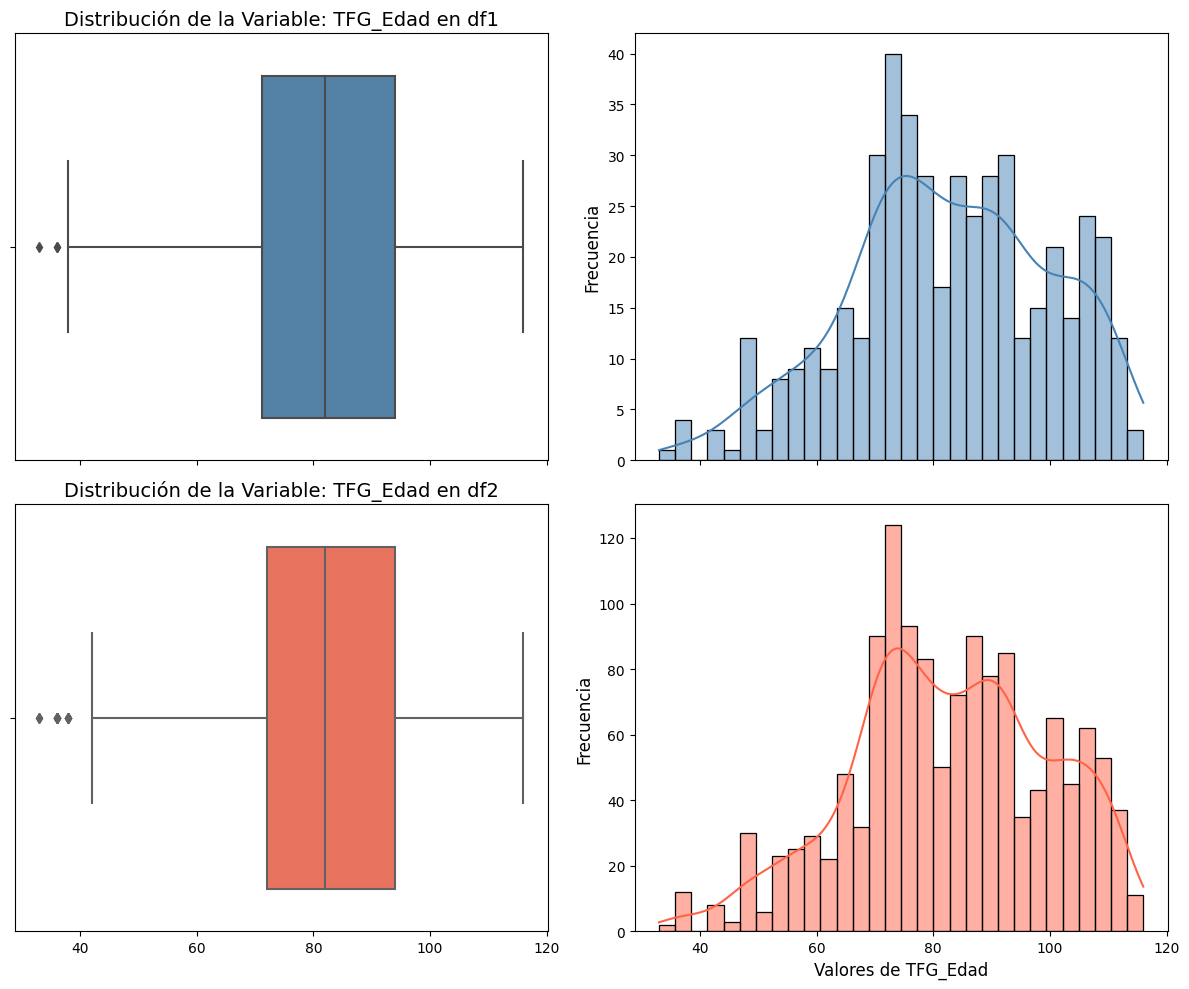

In [43]:
analizar_misma_variable(df_original,df_imputed,"TFG_Edad")

In [44]:
pd.concat([df_original["TFG_Edad"].describe(), df_imputed["TFG_Edad"].describe()], axis=1, 
          keys=["Original", "Imputado"])

,Original,Imputado
count,470.000000,1356.000000
mean,82.536170,82.715339
std,17.417419,17.073709
min,33.000000,33.000000
25%,71.250000,72.000000
50%,82.000000,82.000000
75%,94.000000,94.000000
max,116.000000,116.000000


In [45]:
prueba_kolmogrov(df_original,df_imputed,"TFG_Edad")

KS statistic: 0.013, p-value: 1.000
No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran


#### **Notas:**

Se llevó a cabo la imputación de las variables ``Creatinina``, ``TFG_CDK_EPI`` y ``TFG_Edad`` mediante un proceso de muestreo aleatorio. Posteriormente, se analizó la distribución de las variables imputadas y se realizó la prueba de Kolmogorov-Smirnov para comparar las distribuciones antes y después de la imputación. Los resultados obtenidos indican que no existen diferencias estadísticamente significativas entre las distribuciones originales y las imputadas, lo que sugiere que las imputaciones se realizaron con éxito y no alteraron de manera relevante las características distribucionales de las variables.

### **Imputación por la Mediana:**

#### **Presion_Sistolica:**

In [46]:
df_imputed = imputacion_por_mediana(df_imputed,"Presion_Sistolica")
df_imputed.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,0.8,108.38,72.0,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,1.4,52.51,104.0,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,1.8,34.45,61.0,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

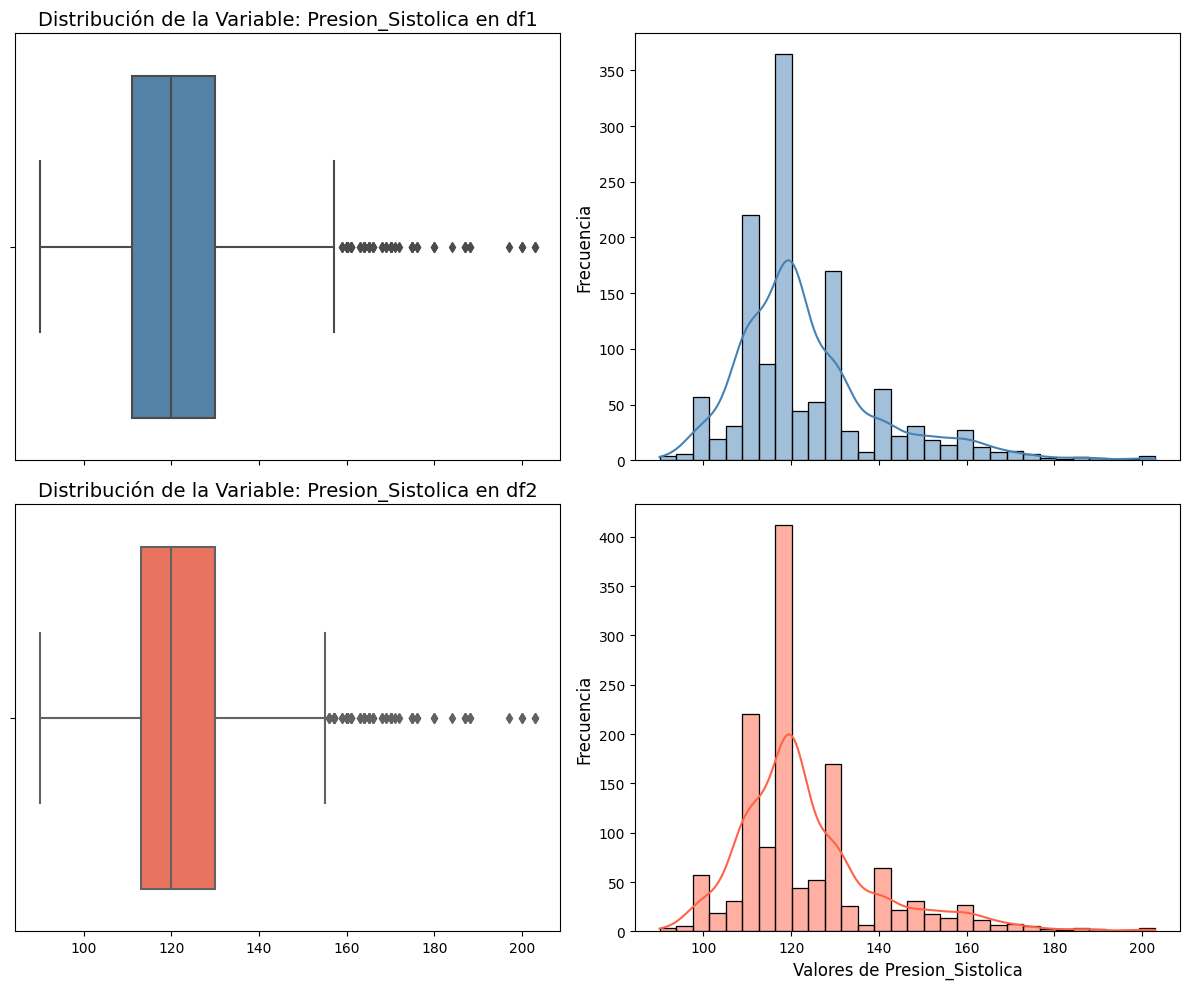

In [47]:
analizar_misma_variable(df_original,df_imputed,"Presion_Sistolica")

c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

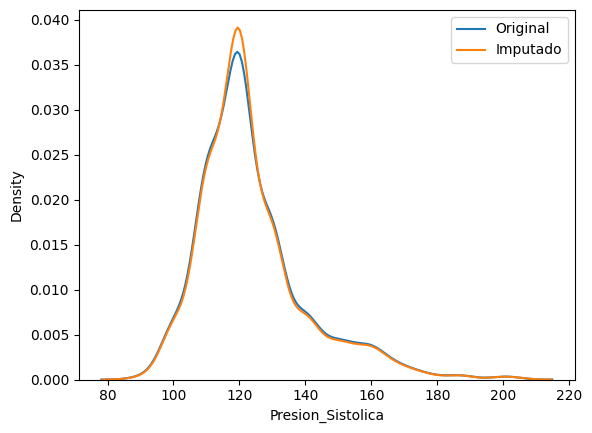

In [48]:
distribucion_cruzada(df_original,df_imputed,"Presion_Sistolica")

In [49]:
pd.concat([df_original["Presion_Sistolica"].describe(), df_imputed["Presion_Sistolica"].describe()], axis=1, 
          keys=["Original", "Imputado"])

,Original,Imputado
count,1309.000000,1356.000000
mean,123.846448,123.713127
std,16.641437,16.365417
min,90.000000,90.000000
25%,111.000000,113.000000
50%,120.000000,120.000000
75%,130.000000,130.000000
max,203.000000,203.000000


In [50]:
prueba_kolmogrov(df_original,df_imputed,"Presion_Sistolica")

KS statistic: 0.014, p-value: 0.999
No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran


#### **Presion_Diastolica:**

In [51]:
df_imputed = imputacion_por_mediana(df_imputed,"Presion_Diastolica")
df_imputed.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,0.8,108.38,72.0,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,1.4,52.51,104.0,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,1.8,34.45,61.0,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

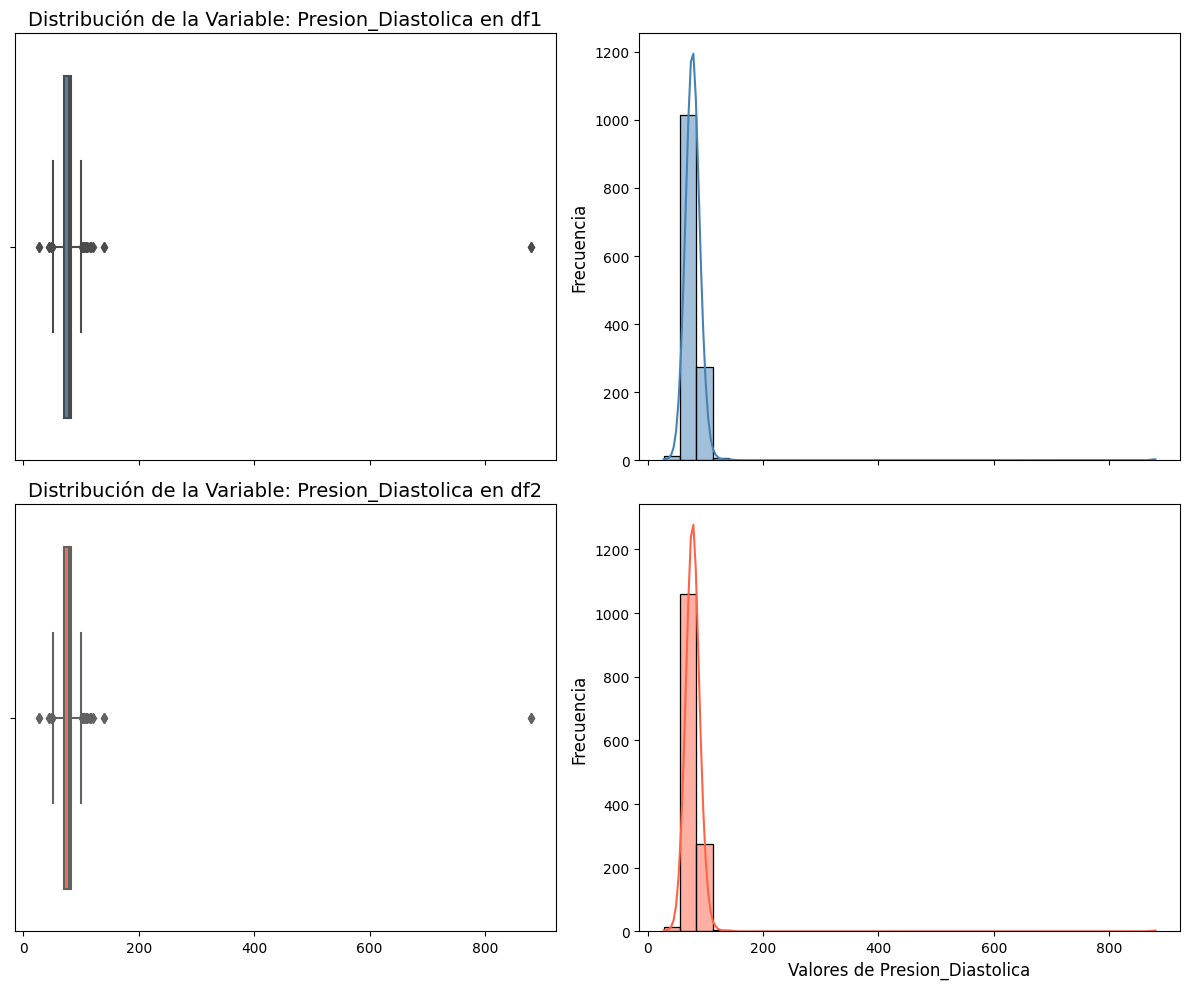

In [52]:
analizar_misma_variable(df_original,df_imputed,"Presion_Diastolica")

c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

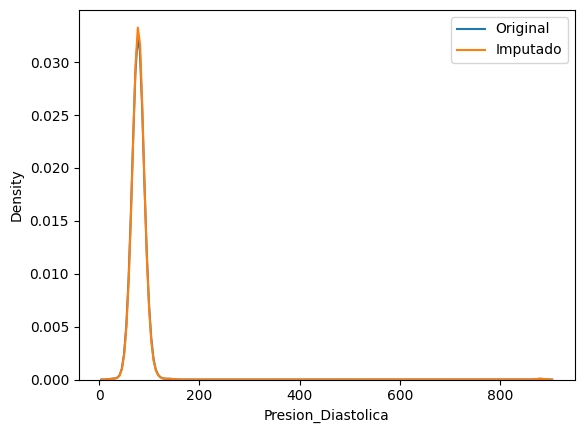

In [53]:
distribucion_cruzada(df_original,df_imputed,"Presion_Diastolica")

In [54]:
pd.concat([df_original["Presion_Diastolica"].describe(), df_imputed["Presion_Diastolica"].describe()], axis=1, 
          keys=["Original", "Imputado"])

,Original,Imputado
count,1309.000000,1356.000000
mean,79.395722,79.416667
std,33.042103,32.464179
min,28.000000,28.000000
25%,70.000000,70.000000
50%,80.000000,80.000000
75%,82.000000,82.000000
max,880.000000,880.000000


In [55]:
prueba_kolmogrov(df_original,df_imputed,"Presion_Diastolica")

KS statistic: 0.016, p-value: 0.994
No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran


#### **Nota:**

Se llevó a cabo la imputación de las variables ``Presion_Sistolica`` y ``Presion_Diastolica`` mediante un proceso de muestreo aleatorio. Posteriormente, se analizó la distribución de las variables imputadas y se realizó la prueba de Kolmogorov-Smirnov para comparar las distribuciones antes y después de la imputación. Los resultados obtenidos indican que no existen diferencias estadísticamente significativas entre las distribuciones originales y las imputadas, lo que sugiere que las imputaciones se realizaron con éxito y no alteraron de manera relevante las características distribucionales de las variables.

### **Revision de Valores Faltantes:**

In [56]:
Resumen_Faltantes(df_imputed)

,Valores faltantes,Porcentaje (%)


c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.draw()
c:\Users\Guirlessa\miniconda3\envs\dl_venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


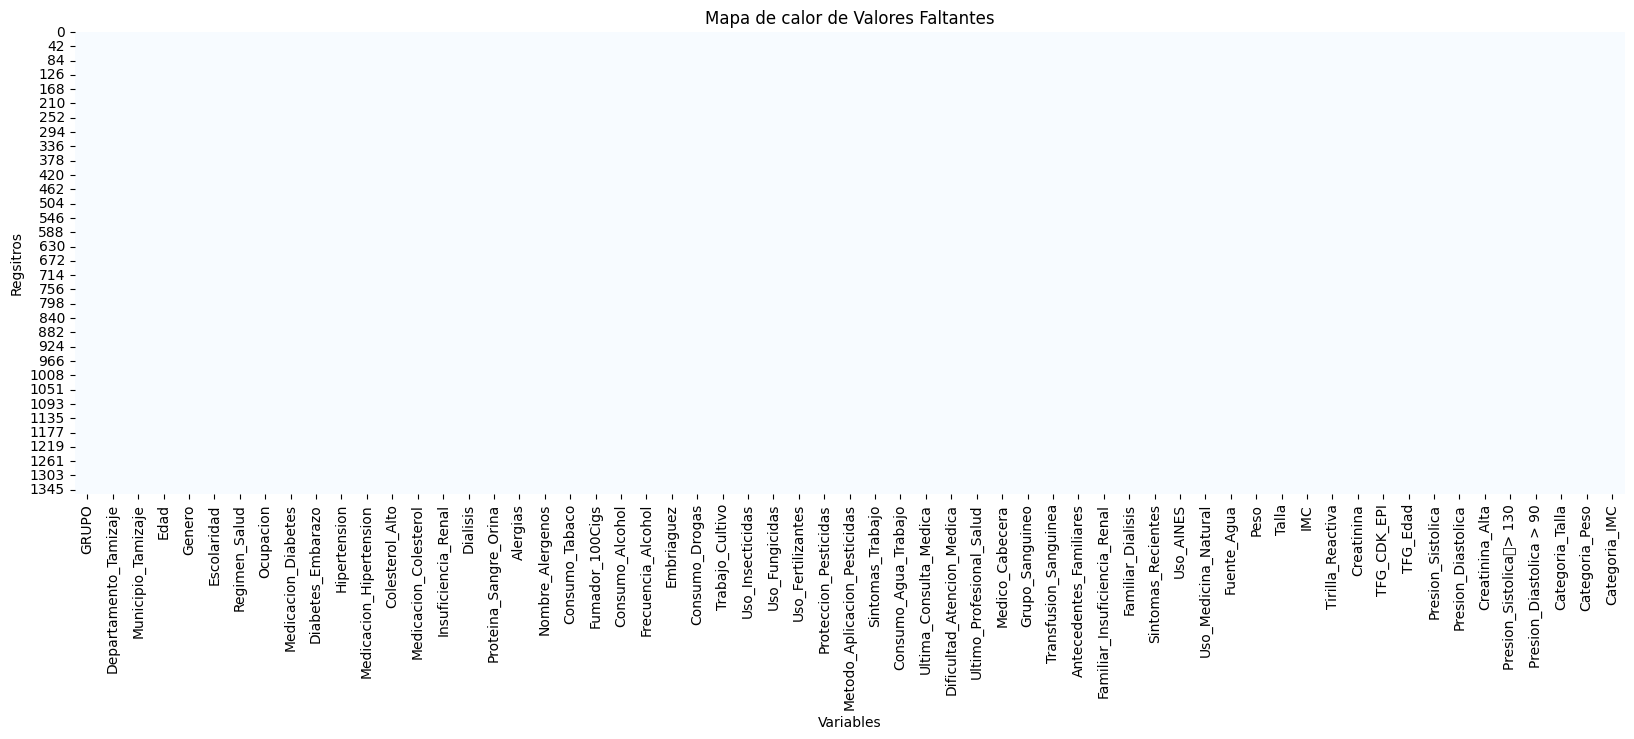

In [57]:
plt.figure(figsize = (20,6))
sns.heatmap(df_imputed.isnull(),cbar=False,cmap= "Blues")
plt.title("Mapa de calor de Valores Faltantes")
plt.xlabel("Variables")
plt.ylabel("Regsitros")
plt.show()

## **Categorizar Daño Renal:**

In [58]:
def daño_renal_grf(x):
    if x >= 90:
        return "Normal"
    elif 60 <= x < 90:
        return "Leve"
    elif 45 <= x < 60:
        return "Leve a moderada"
    elif 30 <= x < 45:
        return "Moderada a severa"
    elif 15 <= x < 30:
        return "Severa"
    elif x == 0:
        return "No hay dato"
    elif x < 15:
        return "Falla renal"

In [59]:
df_imputed["Tipo_Insuficiencia_Renal"] = df_imputed["TFG_CDK_EPI"].apply(daño_renal_grf)
df_original["Tipo_Insuficiencia_Renal"] = df_original["TFG_CDK_EPI"].apply(daño_renal_grf)

In [60]:
resumen_var_cat(df_imputed["Tipo_Insuficiencia_Renal"])

,categorias,conteo,porcentaje
0,Normal,536,39.53%
1,Leve,413,30.46%
2,Leve a moderada,226,16.67%
3,Moderada a severa,150,11.06%
4,Severa,31,2.29%


In [71]:
resumen_var_cat(df_original["Tipo_Insuficiencia_Renal"], excluir="None")

,categorias,conteo,porcentaje
0,None,886,65.34%
1,Normal,184,13.57%
2,Leve,145,10.69%
3,Leve a moderada,80,5.90%
4,Moderada a severa,53,3.91%
5,Severa,8,0.59%


In [62]:
pd.crosstab(
    df_imputed["Tipo_Insuficiencia_Renal"],
    df_imputed["Insuficiencia_Renal"],
    rownames=["Tipo de insuficiencia renal"],
    colnames=["Insuficiencia renal"]
)

Insuficiencia renal,No,Sí
Tipo de insuficiencia renal,,
Leve,386,27
Leve a moderada,198,28
Moderada a severa,132,18
Normal,513,23
Severa,27,4


In [63]:
df_imputed.loc[
    df_imputed["Tipo_Insuficiencia_Renal"] == "Falla renal",
    ["Tipo_Insuficiencia_Renal", "Insuficiencia_Renal", "TFG_CDK_EPI"]
]

,Tipo_Insuficiencia_Renal,Insuficiencia_Renal,TFG_CDK_EPI


In [64]:
pd.crosstab(
    df_original["Tipo_Insuficiencia_Renal"],
    df_original["Insuficiencia_Renal"],
    rownames=["Tipo de insuficiencia renal"],
    colnames=["Insuficiencia renal"]
)

Insuficiencia renal,No,Sí
Tipo de insuficiencia renal,,
Leve,123,22
Leve a moderada,56,24
Moderada a severa,35,18
Normal,167,17
Severa,4,4


In [65]:
resumen_var_cat(df_imputed["Tipo_Insuficiencia_Renal"])

,categorias,conteo,porcentaje
0,Normal,536,39.53%
1,Leve,413,30.46%
2,Leve a moderada,226,16.67%
3,Moderada a severa,150,11.06%
4,Severa,31,2.29%


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1356 entries, 0 to 1356
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GRUPO                         1356 non-null   object 
 1   Departamento_Tamizaje         1356 non-null   object 
 2   Municipio_Tamizaje            1356 non-null   object 
 3   Edad                          1356 non-null   int64  
 4   Genero                        1356 non-null   object 
 5   Escolaridad                   1356 non-null   object 
 6   Regimen_Salud                 1356 non-null   object 
 7   Ocupacion                     1356 non-null   object 
 8   Medicacion_Diabetes           1356 non-null   object 
 9   Diabetes_Embarazo             1356 non-null   object 
 10  Hipertension                  1356 non-null   object 
 11  Medicacion_Hipertension       1356 non-null   object 
 12  Colesterol_Alto               1356 non-null   object 
 13  Medicaci

In [67]:
pd.crosstab(
    df_original["Regimen_Salud"],
    df_original["Medico_Cabecera"],
    rownames=["Regimen de salud"],
    colnames=["Medico de cabecera"]
)

Medico de cabecera,No,Si
Regimen de salud,,
Contributivo,213,93
Especial,22,31
N.d.,1,0
No tiene,80,9
Subsidiado,790,117


In [73]:
pd.crosstab(
    df_original["Genero"],
    df_original["Diabetes_Embarazo"],
    rownames=["Genero"],
    colnames=["Diabetes en el embarazo"]
)

Diabetes en el embarazo,No,No aplica,Sí
Genero,,,
Femenino,805,70,2
Masculino,51,428,0


In [74]:
pd.crosstab(
    df_original["Genero"],
    df_original["Diabetes_Embarazo"],
    rownames=["Genero"],
    colnames=["Diabetes en el embarazo"],
    normalize="index"
)

Diabetes en el embarazo,No,No aplica,Sí
Genero,,,
Femenino,0.917902,0.079818,0.002281
Masculino,0.106472,0.893528,0.000000
